> **Snap Market model series.** We start from Carl's baseline momentum model and iterate to test it and improve it.
>
> **Notebook 10 — quoted-odds statistics.** Describe the odds each model would quote (mean, median, quartiles, spread) to understand how differently they price.

# 10 — Quoted-odds statistics by model

To understand how differently the models price, we look at the **odds each one quotes** on a
balanced book (`flat_book_odds`, which isolates the model's pricing from the live inventory skew),
over the common out-of-sample range. For each model we pool both sides (up and down) across every
second and report full descriptive statistics, plus the implied **offered margin** (the vig baked
into each quote). Box plots show the spread.

Note: `flat_book_odds` uses the displayed probability and the static margin; for model 3 it does
not include the dynamic live-book risk margin (that only applies during a simulation).

In [1]:
import os
import sys

# Move up one level to the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# Add the new current directory to the Python path
sys.path.insert(0, os.getcwd())

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from snapmarket.data import load_oracle_prices
from snapmarket.features import build_features
from snapmarket.parameters import SharedParameters
from snapmarket.models import build_model
from snapmarket.experiments import common_evaluation_start

shared_parameters = SharedParameters()
features = build_features(load_oracle_prices(), shared_parameters)

model_names = [
    "momentum_lookup", "momentum_lookup_rolling", "volatility_regime_momentum",
    "momentum_logistic_rolling", "hidden_symmetric_margin", "guarded_volatility_regime_momentum",
]
models = {name: build_model(name, features, shared_parameters) for name in model_names}
evaluation_index = np.arange(common_evaluation_start(models.values()), features.number_of_seconds)
print(f"{len(evaluation_index):,} seconds of out-of-sample quotes per model")

8,697,067 seconds of out-of-sample quotes per model


In [3]:
def quoted_odds_and_margin(model):
    odds_up, odds_down = model.flat_book_odds(evaluation_index)
    pooled_odds = np.concatenate([odds_up, odds_down])
    offered_margin = 1.0 - 1.0 / (1.0 / odds_up + 1.0 / odds_down)
    return pooled_odds, offered_margin

def describe(values):
    minimum, p5, q1, median, q3, p95, maximum = np.percentile(values, [0, 5, 25, 50, 75, 95, 100])
    return {"mean": values.mean(), "std": values.std(), "min": minimum, "p5": p5,
            "q1": q1, "median": median, "q3": q3, "p95": p95, "max": maximum}

odds_by_model = {}
margin_by_model = {}
odds_stats = {}
margin_stats = {}
for name, model in models.items():
    odds, margin = quoted_odds_and_margin(model)
    odds_by_model[name], margin_by_model[name] = odds, margin
    odds_stats[name] = describe(odds)
    margin_stats[name] = describe(margin)

## Quoted decimal odds (both sides pooled)

In [4]:
odds_table = pd.DataFrame(odds_stats).T.reindex(model_names)
print(odds_table.round(3).to_string())

                                     mean    std    min     p5     q1  median     q3    p95    max
momentum_lookup                     1.759  0.127  1.544  1.557  1.660   1.750  1.850  1.998  2.020
momentum_lookup_rolling             1.756  0.102  1.547  1.602  1.672   1.750  1.836  1.928  2.015
volatility_regime_momentum          1.756  0.103  1.425  1.603  1.691   1.750  1.814  1.926  2.266
momentum_logistic_rolling           1.769  0.202  0.893  1.514  1.666   1.750  1.843  2.073  5.000
hidden_symmetric_margin             1.731  0.059  1.020  1.613  1.750   1.750  1.750  1.750  1.750
guarded_volatility_regime_momentum  1.749  0.108  0.980  1.576  1.686   1.744  1.808  1.919  2.266


## Offered margin per quote (the vig baked into the odds)

In [5]:
margin_table = pd.DataFrame(margin_stats).T.reindex(model_names)
print(margin_table.map(lambda value: f"{value:.3%}").to_string())

                                       mean     std      min       p5       q1   median       q3      p95      max
momentum_lookup                     12.500%  0.000%  12.500%  12.500%  12.500%  12.500%  12.500%  12.500%  12.500%
momentum_lookup_rolling             12.500%  0.000%  12.500%  12.500%  12.500%  12.500%  12.500%  12.500%  12.500%
volatility_regime_momentum          12.500%  0.000%  12.500%  12.500%  12.500%  12.500%  12.500%  12.500%  12.500%
momentum_logistic_rolling           12.501%  0.084%  12.500%  12.500%  12.500%  12.500%  12.500%  12.500%  24.242%
hidden_symmetric_margin             13.429%  2.952%  12.500%  12.500%  12.500%  12.500%  12.500%  19.373%  49.000%
guarded_volatility_regime_momentum  12.857%  1.831%  12.500%  12.500%  12.500%  12.500%  12.500%  14.267%  49.000%


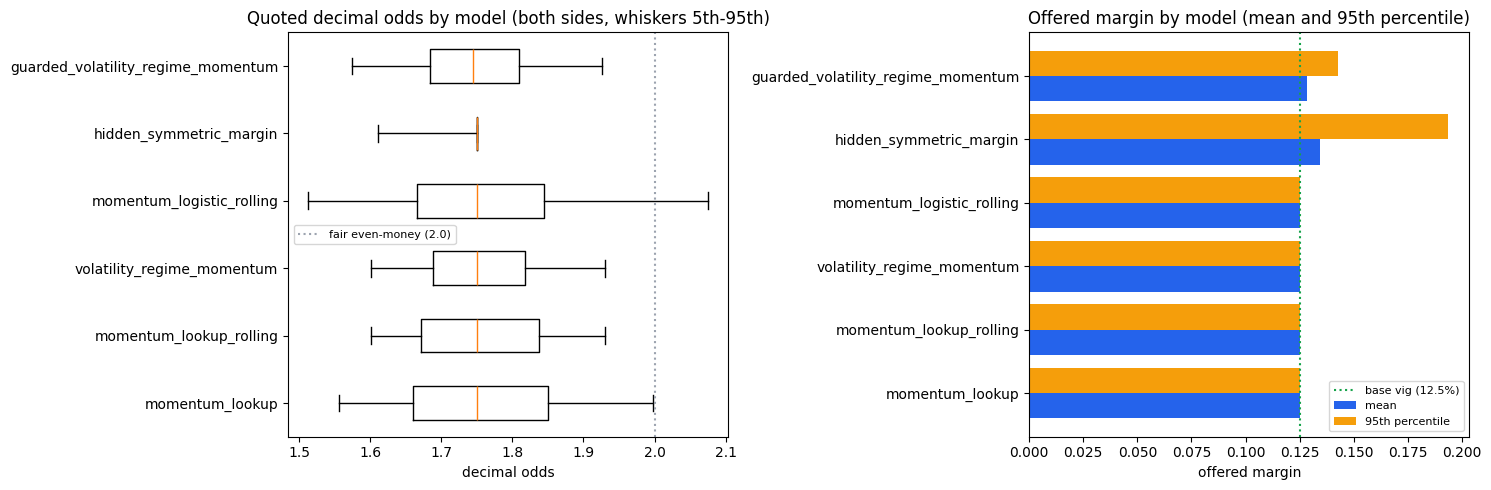

In [6]:
subsample = 50  # thin the arrays just for the box plot
labels = model_names
odds_data = [odds_by_model[name][::subsample] for name in labels]
positions = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: full distribution of quoted odds (box = quartiles, whiskers = 5th-95th).
axes[0].boxplot(odds_data, vert=False, tick_labels=labels, showfliers=False, whis=(5, 95))
axes[0].axvline(2.0, ls=":", color="#9ca3af", label="fair even-money (2.0)")
axes[0].set_title("Quoted decimal odds by model (both sides, whiskers 5th-95th)")
axes[0].set_xlabel("decimal odds"); axes[0].legend(fontsize=8)

# Right: offered margin is ~12.5% almost always, so show its mean and 95th percentile instead.
mean_margin = [margin_stats[name]["mean"] for name in labels]
p95_margin = [margin_stats[name]["p95"] for name in labels]
axes[1].barh(positions - 0.2, mean_margin, height=0.4, color="#2563eb", label="mean")
axes[1].barh(positions + 0.2, p95_margin, height=0.4, color="#f59e0b", label="95th percentile")
axes[1].axvline(shared_parameters.house_margin, ls=":", color="#16a34a",
                label=f"base vig ({shared_parameters.house_margin:.1%})")
axes[1].set_yticks(positions); axes[1].set_yticklabels(labels)
axes[1].set_title("Offered margin by model (mean and 95th percentile)")
axes[1].set_xlabel("offered margin"); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## How to read this

- **`hidden_symmetric_margin` (model 3)** has the **tightest** odds: it shows P=0.50 every second, so
  both sides sit almost exactly at 1.75 (= 2 x (1 - vig)); the only spread comes from its information
  margin occasionally widening (odds dip toward the minimum). It never moves the direction.
- **The momentum / regime models** move the odds with the signal, so their distributions are wider
  and their median stays near 1.75 with quartiles spreading out as momentum gets stronger.
- **`momentum_logistic_rolling`** is the **widest and most extreme**: its confident probabilities push
  the favoured side's odds very short (even below 1.0 in the tail) and the other side toward the 5.0
  cap. That is the price of displaying a rich, high-conviction estimate.
- **Offered margin**: the vig-only models all sit at the base vig (~12.5%) with little variation
  (they only price direction, not extra margin), while model 3 and the guarded model carry a higher,
  more variable margin (their information margin on top of the vig).

So the "spread of quoted odds" ranks: model 3 (narrow, symmetric) < lookup/regime (moderate) <
logistic (wide, extreme). The wider a model quotes, the more sharply it is taking a view on direction.